## Personal Notebook, SVMs (Support Vector Machines), Lotta Kauppinen

##### Using the cleaned_100k.csv and the same skeleton as in the assignment notebook.

### Imports

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

### Reading the CSV and split 60/20/20

In [14]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Shared skeleton

In [15]:
# Agreed 10-feature list
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True):

    steps = []

    # 1. scaling
    steps.append(("scaler", StandardScaler()))

    # 2. SMOTE (vain train-dataan)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))

    # 3. PCA (valinnainen)
    if use_pca:
        steps.append(("pca", PCA()))

    # 4. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

### SVMs: Baseline, PCA, SMOTE, SMOTE + PCA

Fitting 3 folds for each of 6 candidates, totalling 18 fits


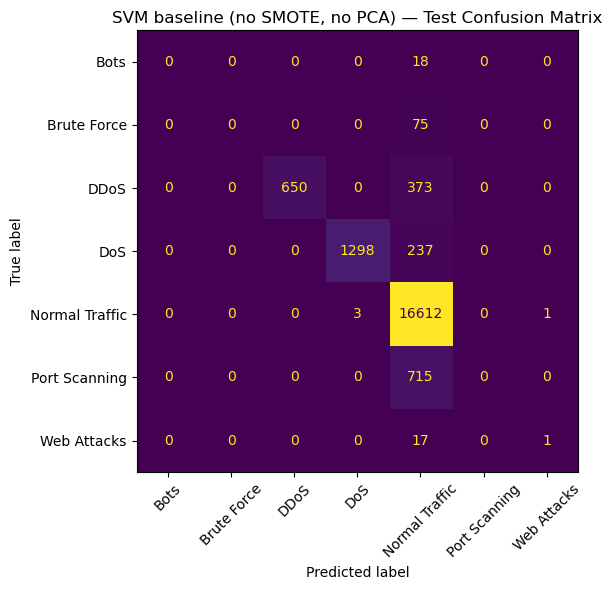


=== SVM baseline (no SMOTE, no PCA) ===
Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Validation acc: 0.9294, f1: 0.3809
Test acc: 0.9281, f1: 0.3930
                precision    recall  f1-score   support

          Bots      0.000     0.000     0.000        18
   Brute Force      0.000     0.000     0.000        75
          DDoS      1.000     0.635     0.777      1023
           DoS      0.998     0.846     0.915      1535
Normal Traffic      0.920     1.000     0.958     16616
 Port Scanning      0.000     0.000     0.000       715
   Web Attacks      0.500     0.056     0.100        18

      accuracy                          0.928     20000
     macro avg      0.488     0.362     0.393     20000
  weighted avg      0.893     0.928     0.906     20000

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


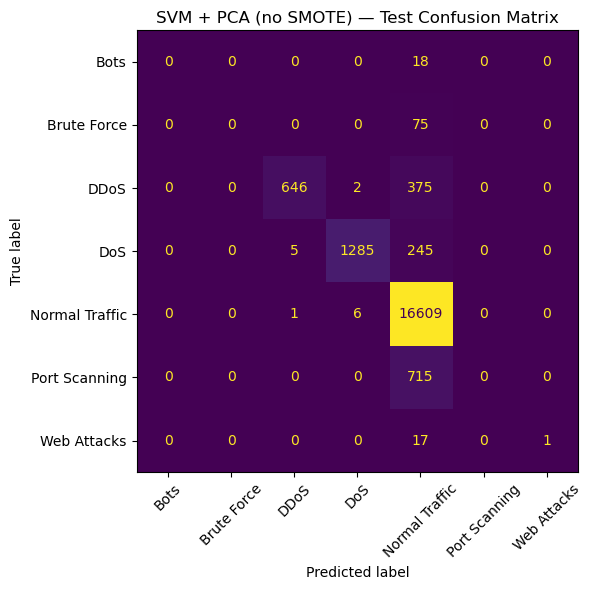


=== SVM + PCA (no SMOTE) ===
Best params: {'clf__C': 10, 'clf__gamma': 'auto', 'clf__kernel': 'rbf', 'pca__n_components': 8}
Validation acc: 0.9284, f1: 0.3791
Test acc: 0.9271, f1: 0.3919
                precision    recall  f1-score   support

          Bots      0.000     0.000     0.000        18
   Brute Force      0.000     0.000     0.000        75
          DDoS      0.991     0.631     0.771      1023
           DoS      0.994     0.837     0.909      1535
Normal Traffic      0.920     1.000     0.958     16616
 Port Scanning      0.000     0.000     0.000       715
   Web Attacks      1.000     0.056     0.105        18

      accuracy                          0.927     20000
     macro avg      0.558     0.361     0.392     20000
  weighted avg      0.892     0.927     0.905     20000

Fitting 3 folds for each of 6 candidates, totalling 18 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


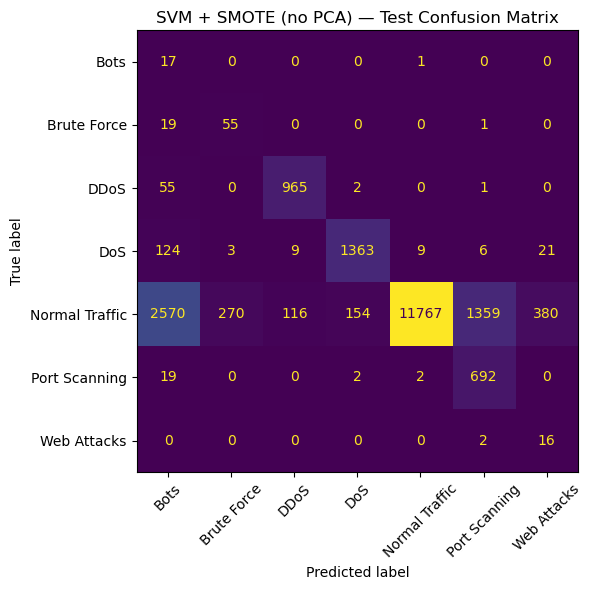


=== SVM + SMOTE (no PCA) ===
Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Validation acc: 0.7406, f1: 0.4933
Test acc: 0.7438, f1: 0.4988
                precision    recall  f1-score   support

          Bots      0.006     0.944     0.012        18
   Brute Force      0.168     0.733     0.273        75
          DDoS      0.885     0.943     0.913      1023
           DoS      0.896     0.888     0.892      1535
Normal Traffic      0.999     0.708     0.829     16616
 Port Scanning      0.336     0.968     0.499       715
   Web Attacks      0.038     0.889     0.074        18

      accuracy                          0.744     20000
     macro avg      0.475     0.868     0.499     20000
  weighted avg      0.957     0.744     0.823     20000

Fitting 3 folds for each of 12 candidates, totalling 36 fits


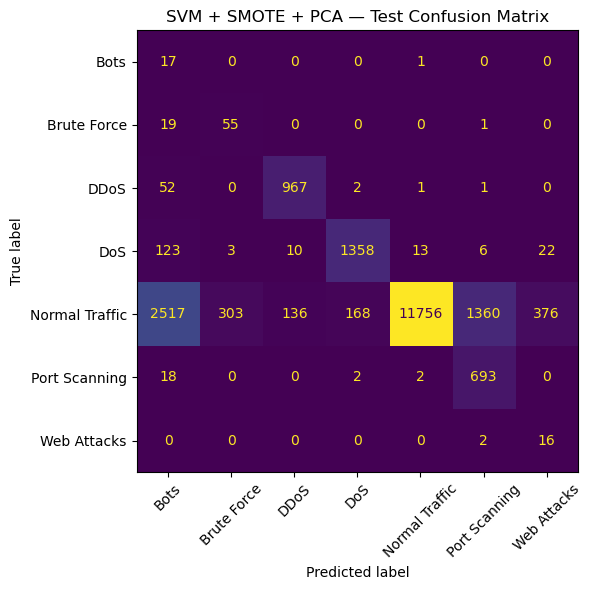


=== SVM + SMOTE + PCA ===
Best params: {'clf__C': 1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf', 'pca__n_components': 8}
Validation acc: 0.7416, f1: 0.4910
Test acc: 0.7431, f1: 0.4939
                precision    recall  f1-score   support

          Bots      0.006     0.944     0.012        18
   Brute Force      0.152     0.733     0.252        75
          DDoS      0.869     0.945     0.905      1023
           DoS      0.888     0.885     0.886      1535
Normal Traffic      0.999     0.708     0.828     16616
 Port Scanning      0.336     0.969     0.499       715
   Web Attacks      0.039     0.889     0.074        18

      accuracy                          0.743     20000
     macro avg      0.470     0.868     0.494     20000
  weighted avg      0.955     0.743     0.821     20000


=== FINAL RESULTS (SVM) ===
                             label  \
2             SVM + SMOTE (no PCA)   
3                SVM + SMOTE + PCA   
0  SVM baseline (no SMOTE, no PCA)   
1             

In [16]:
# Define SVM
svm_clf = SVC()

# Param grid WITH PCA
svm_param_grid_pca = {
    "pca__n_components": [5, 8],
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["rbf"],
    "clf__gamma": ["scale", "auto"]
}

# Param grid WITHOUT PCA
svm_param_grid_no_pca = {
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["rbf"],
    "clf__gamma": ["scale", "auto"]
}

all_results = []

# 1. BASELINE (ei SMOTE, ei PCA)
all_results.append(run_experiment(
    SVC(),
    svm_param_grid_no_pca,
    "SVM baseline (no SMOTE, no PCA)",
    use_smote=False,
    use_pca=False
))

# 2. PCA only
all_results.append(run_experiment(
    SVC(),
    svm_param_grid_pca,
    "SVM + PCA (no SMOTE)",
    use_smote=False,
    use_pca=True
))

# 3. SMOTE only
all_results.append(run_experiment(
    SVC(),
    svm_param_grid_no_pca,
    "SVM + SMOTE (no PCA)",
    use_smote=True,
    use_pca=False
))

# 4. SMOTE + PCA (best candidate)
all_results.append(run_experiment(
    SVC(),
    svm_param_grid_pca,
    "SVM + SMOTE + PCA",
    use_smote=True,
    use_pca=True
))

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by="test_f1_macro",
    ascending=False
)

print("\n=== FINAL RESULTS (SVM) ===")
print(results_df)

best_idx = results_df.index[0]
best_label = results_df.loc[best_idx, "label"]

print("Best model:", best_label)

#### Baseline
##### The baseline model has a high accuracy score, but the macro F1-score is low. This and the other results show us that the model failed to detect several attack types, due to severe class imbalances.

#### With PCA
##### PCA did not improve the performance which tells us that most likely dimensionality is not the key problem that is affecting the model.

#### With SMOTE
##### SMOTE increased the macro F1-score which shows us that the model was able to detect minority attack classes also. However, this lowered the overall accuracy. This is due to the model becoming more sensitive to minority classes and less biased toward the majority class.

#### SMOTE + PCA
##### Using SMOTE and PCA did not provide any major improvement. This indicates that the use of PCA is not as beneficial for SVM as SMOTE.